## Simulating the dataset

Runs in the **eztao** environment. Imports `LightCurves` only; never touches jax. The `.npz`
files written at the end are the entire interface to the training side, so the two environments
never have to agree on numpy, matplotlib or scipy versions.

In [1]:
%load_ext autoreload
%autoreload 2
import numpy as np
import os
import matplotlib, matplotlib.pyplot as plt
from Style import useAA
from LightCurves import MultibandLCGenerator, makeDataset, saveDataset, plotLC

useAA()
DATA = "/Users/anacecilialr/GitHub/MASS/MASS-Thesis/data"
os.makedirs(DATA, exist_ok=True)

# Yu+25 fiducial g-band driver, 3-year baseline
TAU, SIG, TMAX = 100.0, 0.112, 365*3
NOBS, GAPFRAC, NGAPS = 130, 0.35, 3

## 1. Is the experiment worth running?

`checkRegime` before generating, not after. Gap-filling difficulty is controlled by a single
dimensionless quantity, $\Delta t/\tau$, because a DRW forgets as $e^{-\Delta t/\tau}$, so the
cadence and the gaps only mean anything relative to $\tau$. Justification of the values chosen for the thesis.

In [5]:
gen = MultibandLCGenerator(bands="g", t_max=TMAX, tau_driver=TAU, sigma_driver=SIG)
gen.describe(); print()
gen.checkRegime(n_obs=NOBS, gap_frac=GAPFRAC, n_gaps=NGAPS)

Simulated bands = 1: g
Driver band = g
Driver sigma = 0.112
Driver tau = 100.0
Driver snr = 1000000.0
Baseline = 1095 d = 10.9 tau

mean cadence =   8.42 d = 0.084 tau
mean gap     = 127.75 d = 1.28 tau
baseline     =   1095 d = 10.9 tau
epochs kept  ~ 84 of 130 attempted


## 2. Generate

In [2]:
train_c, val_c = makeDataset(
    n_curves=3000, val_frac=0.2, seed0=0,
    gen_kwargs=dict(bands="g", t_max=TMAX, tau_driver=None, sigma_driver=SIG),
    lc_kwargs=dict(n_obs=NOBS, gap_frac=GAPFRAC, n_gaps=NGAPS, sigma_phot=0.01),
)
n = np.array([c["t_obs"].size for c in train_c])
print(f"{len(train_c)} train / {len(val_c)} val")
print(f"epochs per curve: {n.min()}-{n.max()} (mean {n.mean():.0f}); "
      f"predicted n_obs*(1-gap_frac) = {NOBS*(1-GAPFRAC):.0f}")

2400 train / 600 val
epochs per curve: 64-108 (mean 84); predicted n_obs*(1-gap_frac) = 84


## 3. Example curves

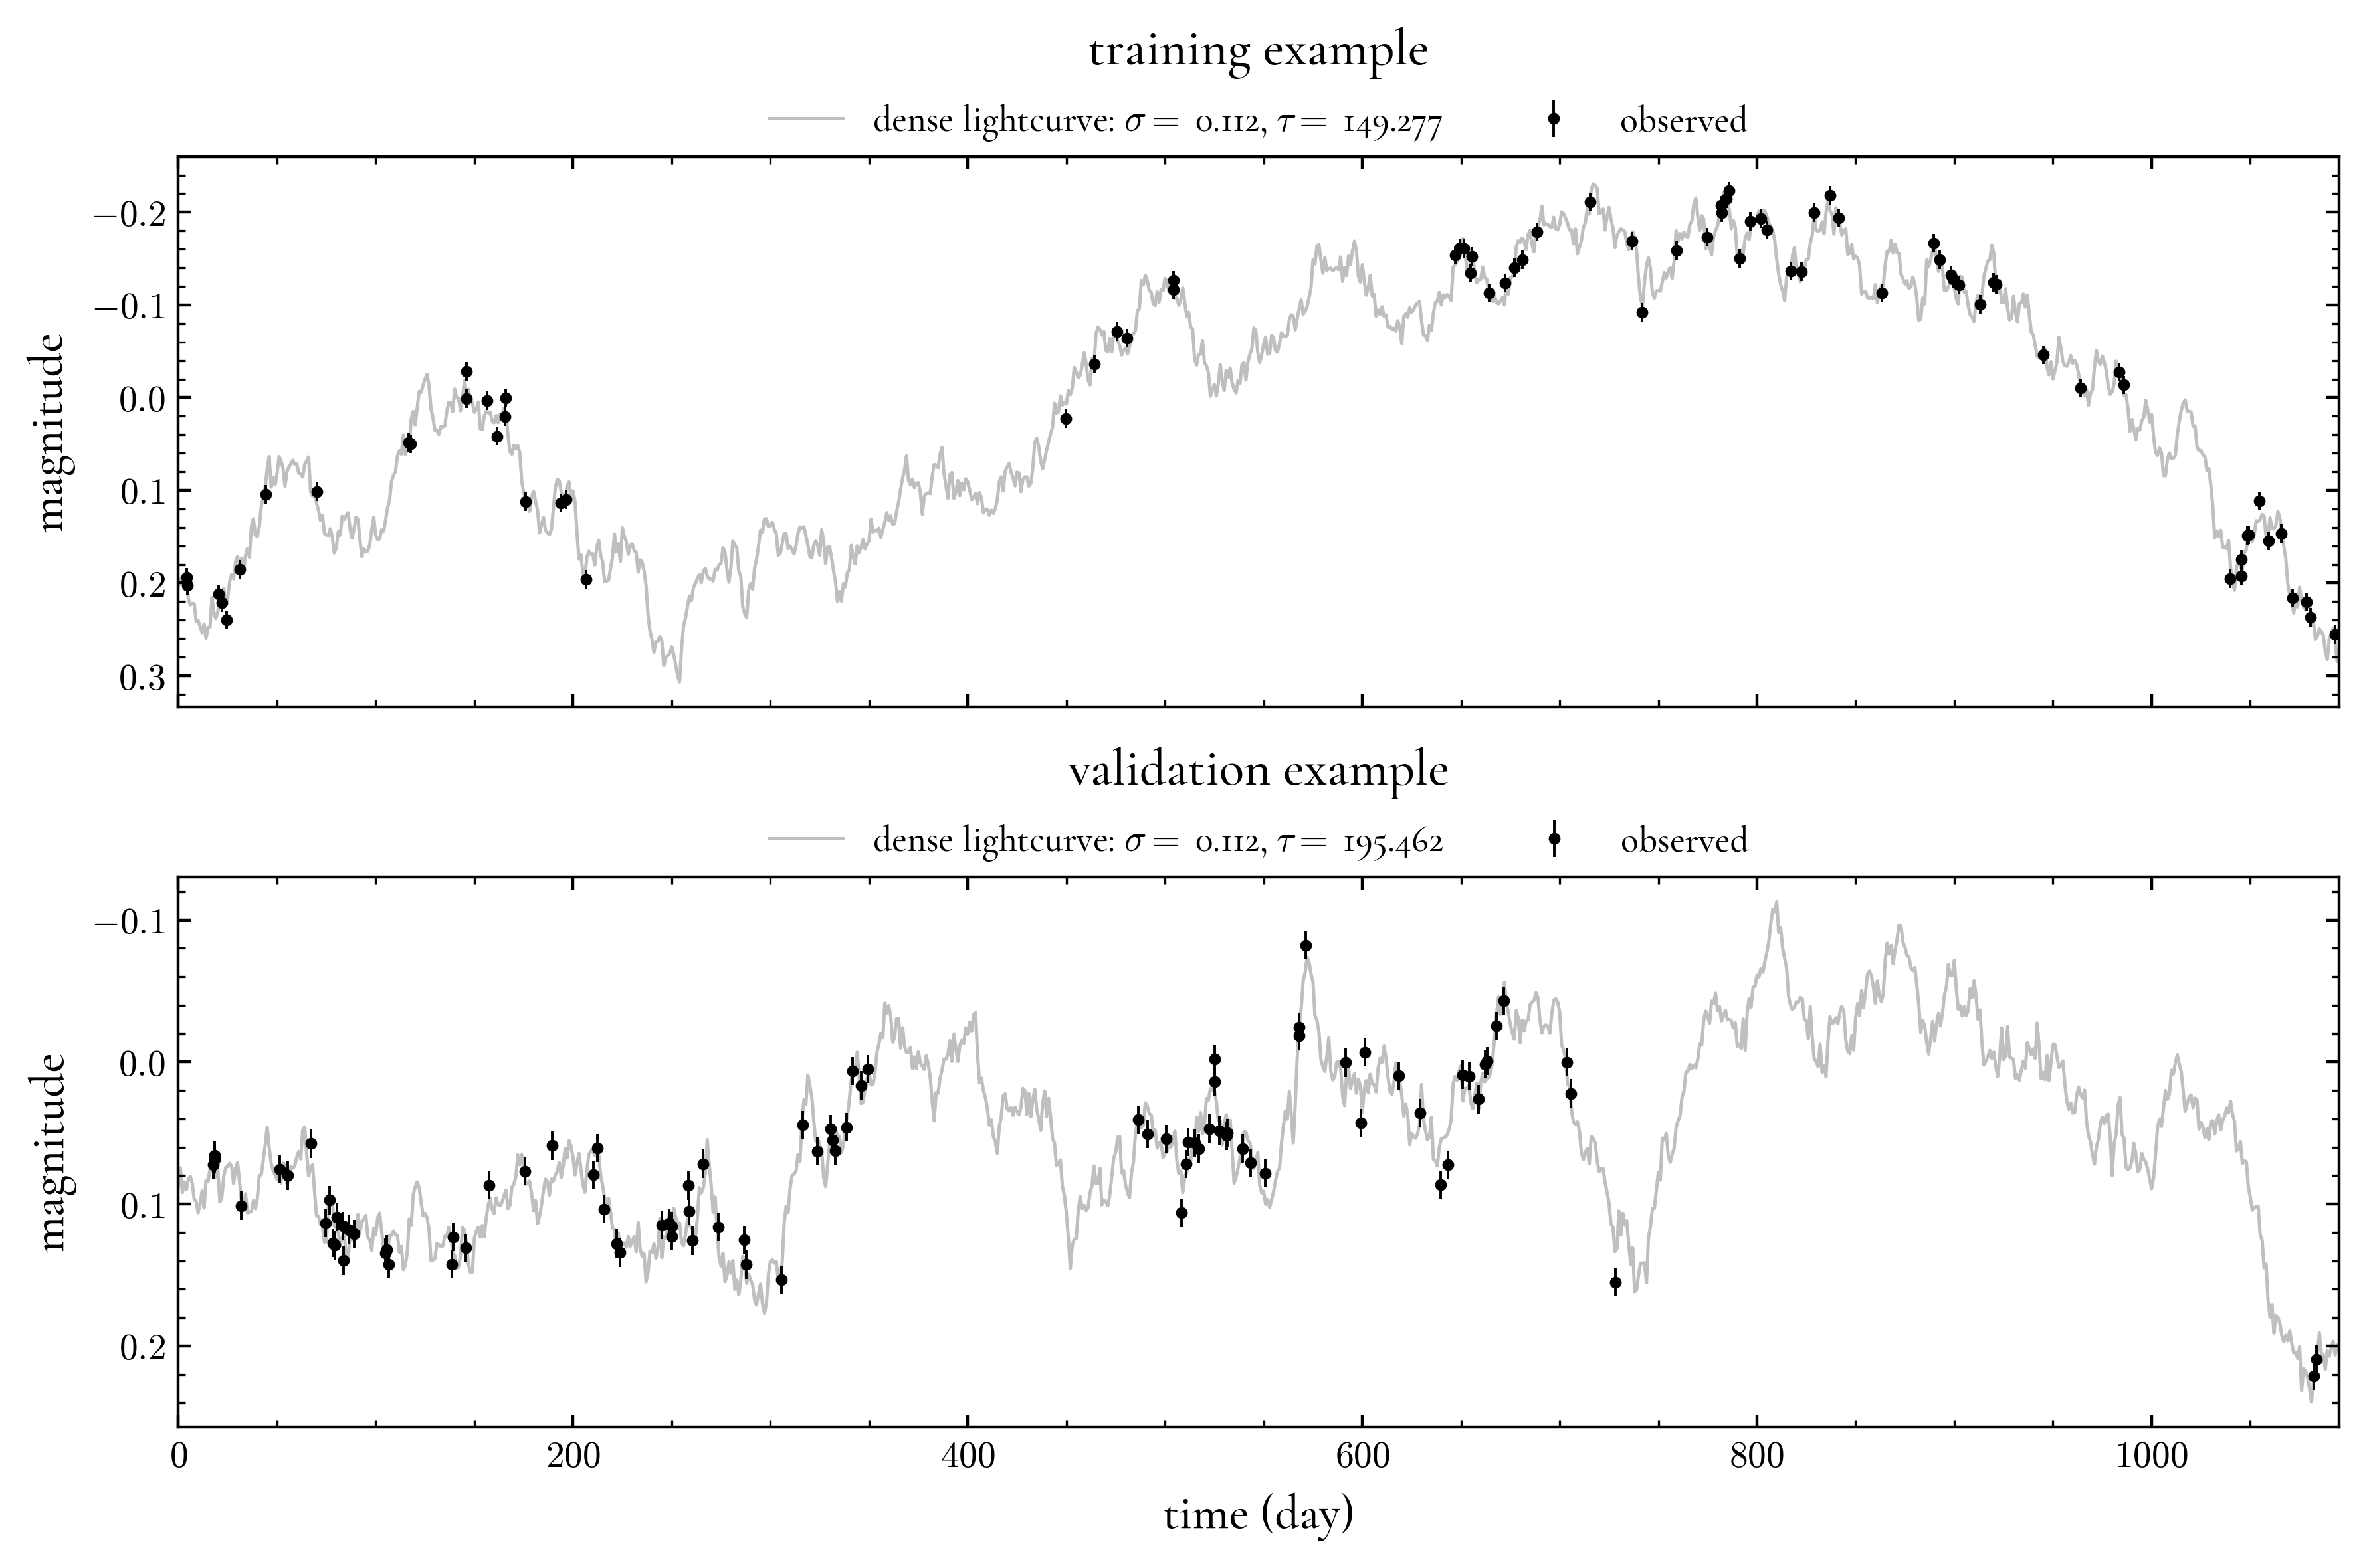

In [4]:
fig, axes = plt.subplots(2, 1, figsize=(9, 6), sharex=True)


plotLC(train_c[90], ax=axes[0])
plotLC(val_c[180],   ax=axes[1])
axes[0].set_title("training example", fontsize=14, pad=25)
axes[1].set_title("validation example", fontsize=14, pad=25)
axes[0].set_xlabel("")
plt.tight_layout()
plt.show()

## 4. Check parameter choises

the **bulk** near $0.08\,\tau$ is the cadence, consecutive epochs strongly correlated;
the **tail** past $\sim\!1\,\tau$ is the gaps, where the DRW has forgotten and reconstruction becomes harder.

If the tail did not reach $\sim\!\tau$, every gap would be trivially interpolable and the thesis
would have no subject. If the bulk sat past $\tau$, consecutive epochs would be uncorrelated and
nothing could be interpolated at all.

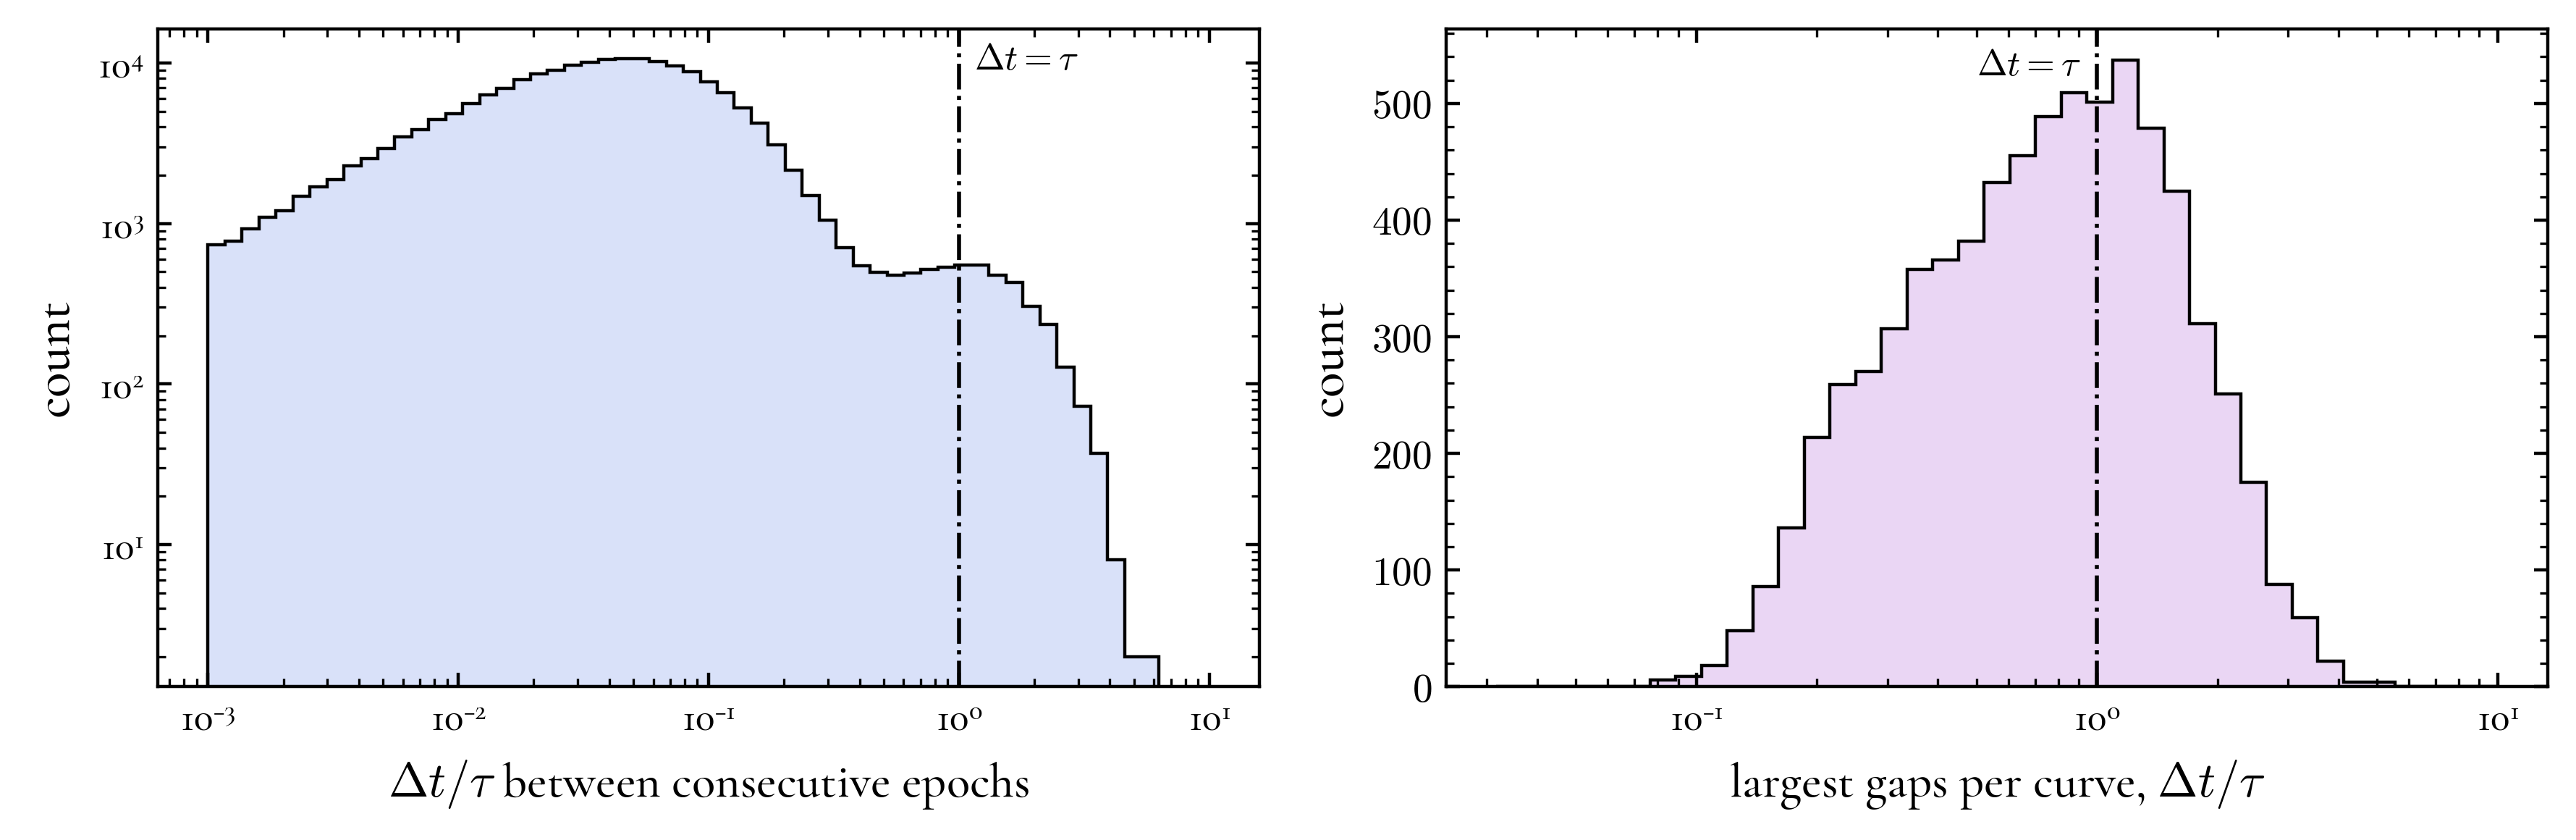

all spacings : median 0.035 tau, 99th pct 1.21 tau
largest gaps : [0.19 0.76 2.26] tau  (5/50/95 pct)
fraction of spacings above 1 tau: 1.3%


In [9]:
dts = np.concatenate([np.diff(c["t_obs"]) / c["tau"] for c in train_c])

fig, ax = plt.subplots(1, 2, figsize=(9, 3))
ax[0].hist(dts, bins=np.logspace(-3, 1, 60), histtype="step", lw=0.8, edgecolor="black")
ax[0].hist(dts, bins=np.logspace(-3, 1, 60), histtype="stepfilled", lw=0.8, edgecolor="none", facecolor="royalblue" , alpha=0.2,)

ax[0].set_xscale("log"); ax[0].set_yscale("log")
ax[0].axvline(1.0, color="k", ls="-.", lw=1)
ax[0].text(1.15, ax[0].get_ylim()[1]*.56, r"$\Delta t=\tau$", fontsize=9)
ax[0].set_xlabel(r"$\Delta t/\tau$ between consecutive epochs", fontsize=12) 
ax[0].set_ylabel("count", fontsize=13)

gaps = np.concatenate([np.sort(np.diff(c["t_obs"]))[-NGAPS:] / c["tau"] for c in train_c])
ax[1].hist(gaps, bins=np.logspace(-1.5, 1, 40), histtype="step", lw=0.8, edgecolor="black")
ax[1].hist(gaps, bins=np.logspace(-1.5, 1, 40), histtype="stepfilled", lw=0.8, edgecolor="none", facecolor="darkorchid", alpha=0.2,)

ax[1].set_xscale("log") 
ax[1].axvline(1.0, color="k", ls="-.", lw=1)
ax[1].text(0.5, ax[1].get_ylim()[1]*0.93, r"$\Delta t=\tau$", fontsize=9)
ax[1].set_xlabel(r"largest gaps per curve, $\Delta t/\tau$", fontsize=12)
ax[1].set_ylabel("count", fontsize=13)
plt.tight_layout()
plt.show()

print(f"all spacings : median {np.median(dts):.3f} tau, 99th pct {np.percentile(dts,99):.2f} tau")
print(f"largest gaps : {np.percentile(gaps,[5,50,95]).round(2)} tau  (5/50/95 pct)")
print(f"fraction of spacings above 1 tau: {100*np.mean(dts>1):.1f}%")

## 5. Save

`saveDataset` pads to the longest curve, stores `t_true` once (it is shared), and pads `yerr` with 1.0

In [12]:
saveDataset(train_c, f"{DATA}/VaryTau/train.npz")
saveDataset(val_c,   f"{DATA}/VaryTau/val.npz")

d = np.load(f"{DATA}/train.npz")
for k in d.files:
    print(f"  {k:12s} {str(d[k].shape):16s} {d[k].dtype}")
print(f"\nsize: {os.path.getsize(f'{DATA}/VaryTau/train.npz')/1e6:.2f} MB")
assert np.all(d["yerr"][~d["mask"]] == 1.0), "yerr padding must be 1.0, not 0.0"
print("padding OK -> Stage 1 can load this in the jax env")

  t_obs        (2400, 108)      float32
  y_obs        (2400, 108)      float32
  yerr         (2400, 108)      float32
  mask         (2400, 108)      bool
  t_true       (1096,)          float32
  y_true       (2400, 1096)     float32
  gap_windows  (2400, 3, 2)     float32
  tau          (2400,)          float32
  sigma        (2400,)          float32
  seed         (2400,)          int64

size: 11.33 MB
padding OK -> Stage 1 can load this in the jax env


## Notes 

**Union grid.** The driver is simulated once on `union(t_true, t_obs)`, so truth and
  observations are slices of the *same* path. Interpolating instead would inject ~0.006 mag of
  error (60% of the 10 mmag photometric noise) because a DRW is a rough (Hölder-1/2) process
  and linear interpolation error only falls as $\sqrt{\Delta t}$.

**`gap_frac` is exact.** Windows are laid out disjointly, wholly inside the baseline, with a
  margin of 3x the mean spacing at each end so a window cannot truncate the light curve instead
  of making a fillable gap.

**$\tau$ fixed at 100 d**, not Yu+25's LogUniform(0.01, 500). Their range probes $\tau$-recovery
  across its failure regimes; ~80% of it would produce degenerate curves here. LogUniform(30, 300)
  is the informative range at this baseline and cadence.

logM_BH: median 8.50  1sigma [8.12, 8.86]
tau_DRW: median 166 d   1sigma [119, 227] d
sample tau (200-300) from this distribution, or bracket LogUniform(119, 227)


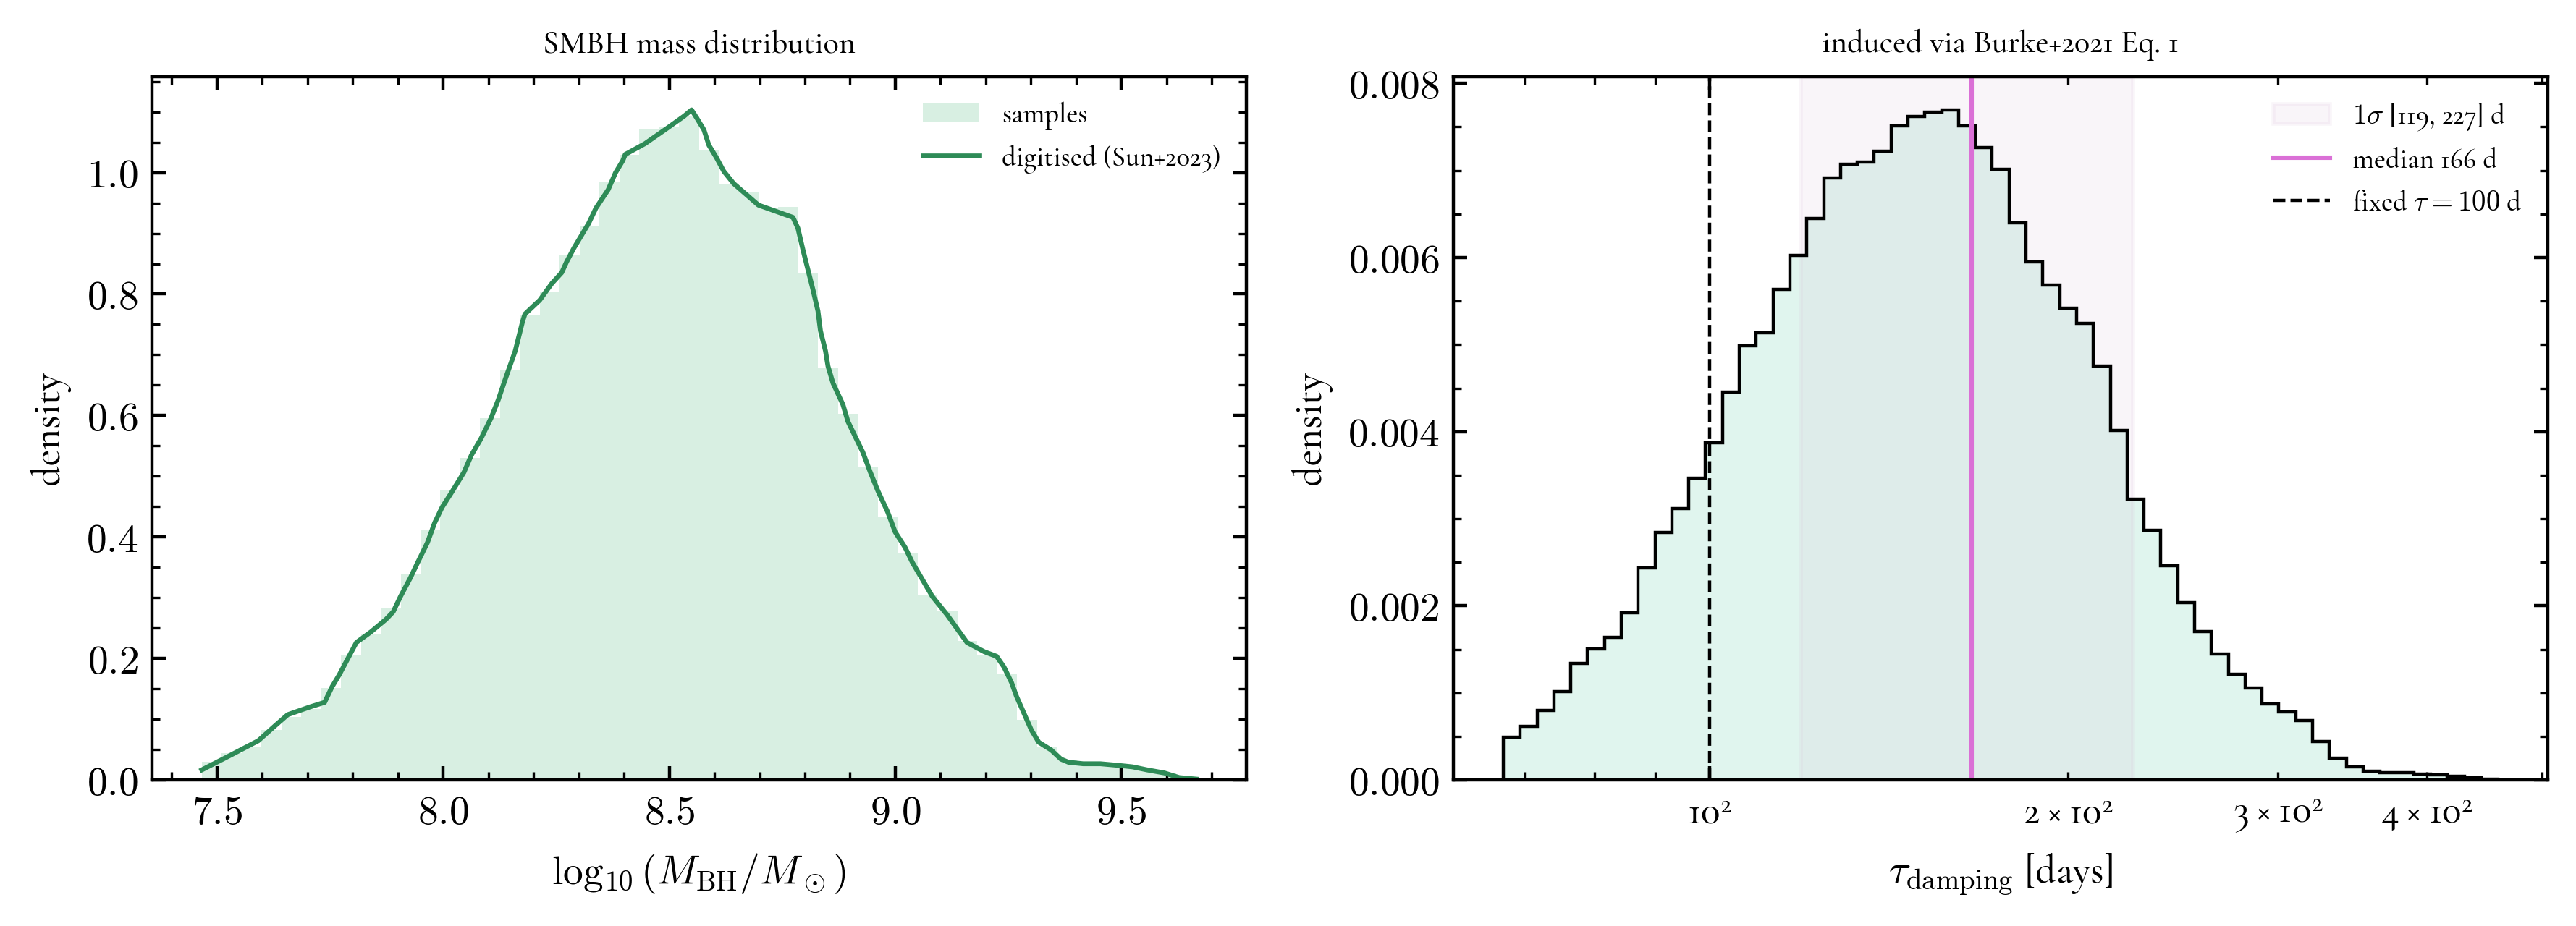

In [ ]:


# Burke+2021, Eq. 1 
#   tau_damping = 107 (+11/-12) d * (M_BH / 10^8 Msun)^0.38 ; rest-frame optical
TAU0, LOGM_PIV, SLOPE = 107.0, 8.0, 0.38


# Sun+2023 bias-corrected logM_BH distribution, model [10s=500, sig_int=0.3 dex]
# of quasars 1.4 < z < 1.8, with a 1.6 median
d = np.loadtxt("/Users/anacecilialr/GitHub/MASS/MASS-Thesis/data/sun_fig4.csv", delimiter=",")        # cols: logM, density
xM, pM = d[:, 0], d[:, 1]
order  = np.argsort(xM); xM, pM = xM[order], pM[order]      
xM, k  = np.unique(xM, return_index=True); pM = pM[k]       
pM     = np.clip(pM, 0, None)   

# normalizing to a PDF                         
pM     = pM / np.trapezoid(pM, xM)                            

# sample logM by inverse-CDF 
cdf  = np.concatenate([[0.0], np.cumsum(0.5 * (pM[1:] + pM[:-1]) * np.diff(xM))])
cdf /= cdf[-1]
rng  = np.random.default_rng(0)
logM = np.interp(rng.uniform(size=400_000), cdf, xM)

# tau
tau = TAU0 * 10.0**(SLOPE * (logM - LOGM_PIV))            # days, rest-frame
lo, med, hi = np.percentile(tau, [16, 50, 84])
print(f"logM_BH: median {np.median(logM):.2f}  1sigma [{np.percentile(logM,16):.2f}, {np.percentile(logM,84):.2f}]")
print(f"tau_DRW: median {med:.0f} d   1sigma [{lo:.0f}, {hi:.0f}] d")
print(f"sample tau (200-300) from this distribution, or bracket LogUniform({lo:.0f}, {hi:.0f})")


fig, ax = plt.subplots(1, 2, figsize=(9, 3.3))

# mass distribution: samples vs the digitised input
#ax[0].hist(logM, bins=50, density=True, histtype="step", lw=0.8, edgecolor="black", label="samples")
ax[0].hist(logM, bins=50, density=True, lw=0.8, edgecolor=None, facecolor="mediumseagreen" , alpha=0.2, label = "samples")

ax[0].plot(xM, pM, lw=1.2, label="digitised (Sun+2023)", color = "seagreen")  
ax[0].set_xlabel(r"$\log_{10}(M_{\rm BH}/M_\odot)$"); ax[0].set_ylabel("density")
ax[0].legend(fontsize=7); ax[0].set_title("SMBH mass distribution", fontsize=8)

# tau distribution with the 1-sigma band
ax[1].hist(tau, bins=np.logspace(np.log10(tau.min()), np.log10(tau.max()), 60),
           density=True, histtype="step", lw=0.8, edgecolor="black")
ax[1].hist(tau, bins=np.logspace(np.log10(tau.min()), np.log10(tau.max()), 60),
           density=True, lw=0.8, edgecolor="none", facecolor="mediumaquamarine" , alpha=0.2)
ax[1].axvspan(lo, hi, color="thistle", alpha=.15, label=r"$1\sigma$ [%.0f, %.0f] d" % (lo, hi))
ax[1].axvline(med, color="orchid", lw=1.1, label="median %.0f d" % med)
ax[1].axvline(100, color="k", lw=.8, ls="--", label=r"fixed $\tau=100$ d")
ax[1].set_xscale("log")
ax[1].set_xlabel(r"$\tau_{\rm damping}$ [days]")
ax[1].set_ylabel("density")
ax[1].legend(fontsize=7); ax[1].set_title("induced via Burke+2021 Eq. 1", fontsize=8)

fig.tight_layout()
plt.savefig("/Users/anacecilialr/GitHub/MASS/MASS-Thesis/assets/5_figures/FixedTauExp/TauDist.pdf")
plt.show()

median 166 d, 1sigma [118, 227]


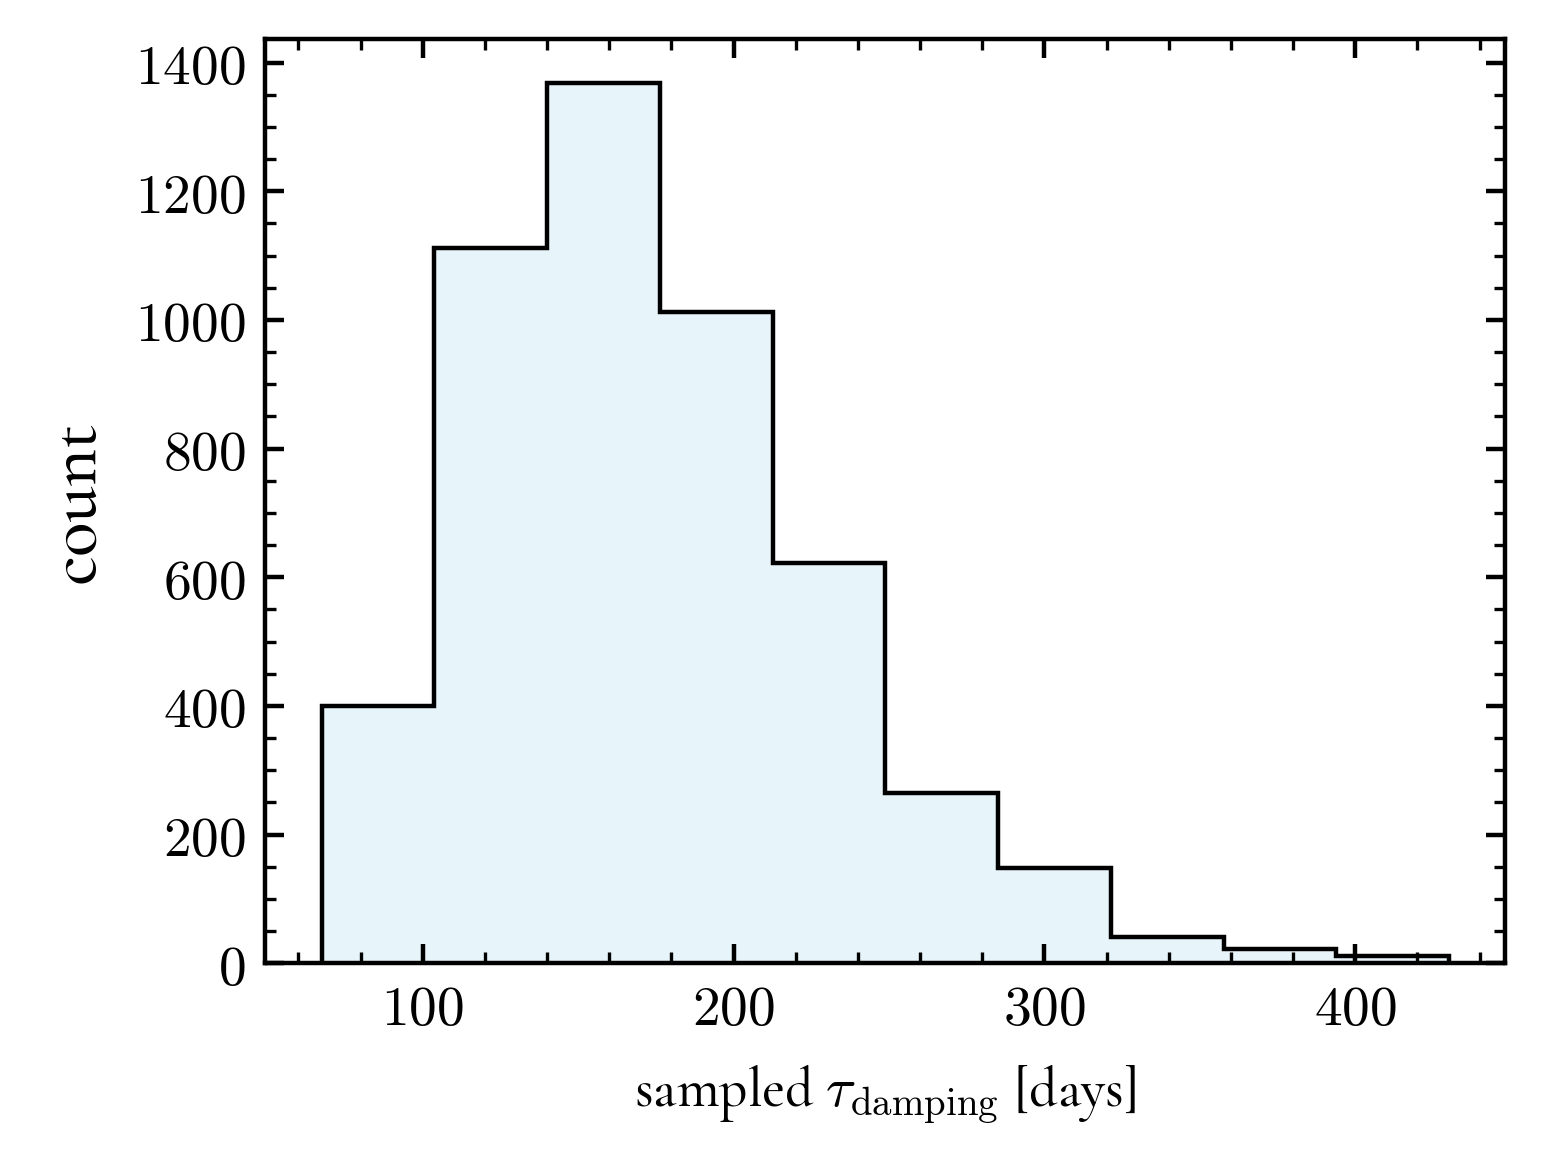

logM peak (median): 8.5027


In [ ]:

plt.figure(figsize=(4, 3))
gen = MultibandLCGenerator(bands="g", tau_driver=None)  
taus = np.array([gen.sampleTau() for _ in range(5000)])
print(f"median {np.median(taus):.0f} d, 1sigma [{np.percentile(taus,16):.0f}, {np.percentile(taus,84):.0f}]")

plt.hist(taus, histtype="step", lw=0.8, edgecolor="black")
plt.hist(taus, histtype="stepfilled", lw=0.8, edgecolor="none", facecolor="skyblue", alpha=0.2)
plt.xlabel(r"sampled $\tau_{\rm damping}$ [days]")
plt.ylabel("count", fontsize=13)

plt.savefig("/Users/anacecilialr/GitHub/MASS/MASS-Thesis/assets/5_figures/FixedTauExp/TauSample.pdf")
plt.show()

cdf, xM = MultibandLCGenerator._loadMassCDF()

print(f"logM peak (median): {np.interp(0.5, cdf, xM):.4f}")

In [ ]:
cdf, xM = MultibandLCGenerator._loadMassCDF()
logM_med = np.interp(0.5, cdf, xM)                    # median MASS
tau_at_logM_med = 107 * 10**(0.38*(logM_med - 8.0))   # tau AT that mass
print(f"median logM = {logM_med:.2f}  ->  tau at median mass = {tau_at_logM_med:.0f} d")
print(f"median of tau samples = {np.median(taus):.0f} d")   # will be HIGHER

median logM = 8.50  ->  tau at median mass = 166 d
median of tau samples = 166 d
